# Phase 3: Preprocessing

This notebook walks through the preprocessing stage that converts raw gene expression data into a machine-learning-ready matrix.

Why this stage matters:
- raw genomic data is noisy and high-dimensional,
- low-variance genes often add computation without improving clustering,
- scaling is important because many downstream models are sensitive to feature magnitude,
- and saving intermediate outputs makes later notebooks faster and more reproducible.

The code cells below import the reusable preprocessing module, execute the full cleaning pipeline, verify the transformed data, and save the outputs needed by later phases.

---

## Cell 1: Import project utilities and the preprocessing module

This cell prepares the notebook runtime and imports the reusable code from `src/preprocessor.py`.

What each part does:
- `sys.path.append('..')` adds the project root to Python's import path so the notebook can import modules from `src/`.
- `importlib.reload(...)` forces Jupyter to reload the module if you changed the source file since the last notebook run.
- `run_preprocessing` is imported as the main entry point so the notebook can execute the entire preprocessing workflow in one call.
- plotting libraries are loaded here because later cells verify the transformed data visually.

This keeps the notebook thin and pushes the real logic into the source module, which is a good pattern for maintainability.

In [1]:
import os
import sys
import importlib
sys.path.append('..')
import src.preprocessor as preprocessor
importlib.reload(preprocessor)
run_preprocessing = preprocessor.run_preprocessing
import matplotlib.pyplot as plt
import numpy as np

print(f"Current working directory: {os.getcwd()}")
print(f"Config exists: {os.path.exists('../config.yaml')}")
print(f"Using preprocessor module: {preprocessor.__file__}")

Current working directory: c:\Users\DELL\OneDrive\Documents\Machine Learning\ML_Projects\Unsupervised Learning\Genome Data Clustering\notebook
Config exists: True
Using preprocessor module: c:\Users\DELL\OneDrive\Documents\Machine Learning\ML_Projects\Unsupervised Learning\Genome Data Clustering\notebook\..\src\preprocessor.py


## Cell 2: Run the full preprocessing pipeline

This cell executes `run_preprocessing('../config.yaml')`, which is the main preprocessing function defined in `src/preprocessor.py`.

Inside that function, the pipeline:
- loads the raw expression and metadata files,
- separates metadata rows from gene expression rows,
- transposes the matrix so rows represent cells and columns represent genes,
- fills missing values when needed,
- removes low-variance genes,
- keeps the top most-variable genes,
- applies `log1p` transformation,
- standardizes the feature matrix,
- and saves processed outputs to disk.

The returned objects are important for later stages:
- `X_scaled` is the standardized numeric matrix used by PCA and clustering,
- `scaler` stores the fitted transformation for future predictions,
- `gene_names` and `cell_names` preserve feature and sample identity,
- `metadata` keeps sample annotations aligned with the cleaned matrix.

In [2]:
X_scaled, scaler, gene_names, cell_names, metadata = run_preprocessing('../config.yaml')

print(f"\nResults:")
print(f"  X_scaled shape: {X_scaled.shape}")
print(f"  Number of genes: {len(gene_names)}")
print(f"  Number of cells: {len(cell_names)}")
print(f"  Metadata columns: {metadata.columns.tolist()}")

STARTING PREPROCESSING PIPELINE
Loading raw data...
  Expression loaded: 4645 genes x 23686 cells
  Metadata loaded:   (4645, 3)
Separating metadata from expression data...
  Metadata rows: 3
  Gene rows: 4642

Transposed shape: (23686, 4642) (cells x genes)
No missing values found ✓
Filtering low-variance genes (removing bottom 20%)...
  Before: 4642 genes
  After:  3713 genes
  Removed: 929 genes
Keeping top 5000 most variable genes...
  Final gene count: 3713
Applying log1p transformation...
  Log transformation complete ✓
Standardizing data (mean=0, std=1)...
  Mean: 0.0000 (should be ~0)
  Std:  1.0000 (should be ~1)

Processed data saved to c:\Users\DELL\OneDrive\Documents\Machine Learning\ML_Projects\Unsupervised Learning\Genome Data Clustering\data\processed\expression_clean.csv

PREPROCESSING COMPLETE
Final shape: (23686, 3713) (cells x genes)

Results:
  X_scaled shape: (23686, 3713)
  Number of genes: 3713
  Number of cells: 23686
  Metadata columns: ['Cy72_CD45_H02_S758_com

## Cell 3: Verify the transformed matrix numerically

This cell performs quick numerical sanity checks on the preprocessing output.

Why these checks matter:
- the matrix shape confirms that filtering and transposition behaved as expected,
- the feature count tells us how much dimensionality remains after gene selection,
- the near-zero mean and near-unit standard deviation confirm that scaling worked,
- and previewing names makes sure cell and gene labels were preserved rather than lost during transformation.

These simple checks catch many pipeline errors early, especially shape mismatches and broken scaling.

In [3]:
print(f"\nVerification:")
print(f"  Mean (should be ~0): {X_scaled.mean():.4f}")
print(f"  Std  (should be ~1): {X_scaled.std():.4f}")
print(f"  Min value: {X_scaled.min():.4f}")
print(f"  Max value: {X_scaled.max():.4f}")


Verification:
  Mean (should be ~0): 0.0000
  Std  (should be ~1): 1.0000
  Min value: -0.8728
  Max value: 6.1661


## Cell 4: Visualize the scaled data distribution

This cell uses histograms to inspect a few representative columns from `X_scaled`.

What the plots help explain:
- whether scaling produced roughly centered feature distributions,
- whether there are extreme outliers in particular features,
- whether any feature looks constant after processing,
- and whether the transformed data is in a stable range for PCA and clustering.

The idea is not to prove the data is perfectly normal, but to confirm the preprocessing step produced a sensible numerical representation.

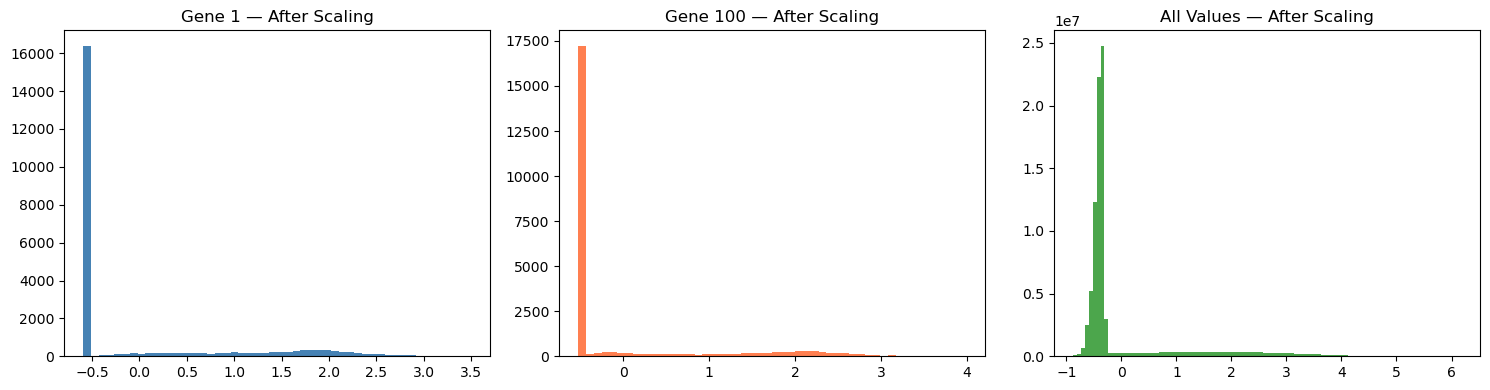

Preprocessing verified!


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(X_scaled[:, 0], bins=50, color='steelblue')
axes[0].set_title("Gene 1 — After Scaling")

axes[1].hist(X_scaled[:, 100], bins=50, color='coral')
axes[1].set_title("Gene 100 — After Scaling")

axes[2].hist(X_scaled.flatten(), bins=100, color='green', alpha=0.7)
axes[2].set_title("All Values — After Scaling")

plt.tight_layout()
plt.savefig('../results/03_preprocessing_result.png', dpi=150)
plt.show()
print("Preprocessing verified!")


## Cell 5: Save the fitted scaler for later inference

This cell persists the fitted `StandardScaler` object with `joblib`.

Why saving the scaler matters:
- future samples must be transformed with exactly the same scaling logic used during training,
- recomputing the scaler on new data would leak information and change the feature distribution,
- and deployment layers like the API depend on this exact object to preprocess incoming samples consistently.

The verification reload is a small but useful integrity check that confirms the saved file can be read back correctly.

In [6]:
# Save scaler to models/ folder
# joblib is better than pickle for numpy arrays (faster, smaller files)
import joblib
scaler_path = '../models/scaler.pkl'
joblib.dump(scaler, scaler_path)

# Verify it saved correctly by loading it back
scaler_loaded = joblib.load(scaler_path)

print('scaler.pkl saved and verified!')
print(f'\nFile location: {scaler_path}')
print(f'File size:     {os.path.getsize(scaler_path) / 1024:.1f} KB')
print(f'\nScaler details:')
print(f'  Type:           {type(scaler)}')
print(f'  Fitted on:      {scaler.n_features_in_} genes')
print(f'  Mean  (first 3 genes): {scaler.mean_[:3].round(4)}')
print(f'  Scale (first 3 genes): {scaler.scale_[:3].round(4)}')
print()
print('WHY this is critical:')
print('  Phase 7 predict_new_patient() loads this file')
print('  New patients MUST be scaled with these exact values')
print('  If missing → Phase 7 Cell 3 will throw FileNotFoundError')

scaler.pkl saved and verified!

File location: ../models/scaler.pkl
File size:     87.6 KB

Scaler details:
  Type:           <class 'sklearn.preprocessing._data.StandardScaler'>
  Fitted on:      3713 genes
  Mean  (first 3 genes): [0.3585 0.3265 0.3799]
  Scale (first 3 genes): [0.6071 0.596  0.6055]

WHY this is critical:
  Phase 7 predict_new_patient() loads this file
  New patients MUST be scaled with these exact values
  If missing → Phase 7 Cell 3 will throw FileNotFoundError


## Cell 6: Save processed arrays and feature metadata

This cell saves the outputs that later notebooks depend on.

What is being written:
- `X_scaled.npy` stores the processed feature matrix in a compact NumPy format,
- `gene_names.txt` preserves the exact feature order used during training,
- `cell_names.txt` preserves row identity for analysis and plotting,
- and the results directory acts as a shared artifact store across notebook phases.

This is important because every later stage assumes the same feature ordering. Saving both the matrix and its labels prevents subtle downstream bugs.

In [7]:
# Save X_scaled so Phase 4 can load it directly
np.save('../results/X_scaled.npy', X_scaled)

# Save gene and cell names as text files
with open('../results/gene_names.txt', 'w') as f:
    f.write('\n'.join(gene_names))

with open('../results/cell_names.txt', 'w') as f:
    f.write('\n'.join(cell_names))

print('All data saved!')
print()
print('Files saved:')
print(f'  models/scaler.pkl              ← used by Phase 7')
print(f'  results/X_scaled.npy           ← used by Phase 4')
print(f'  results/gene_names.txt         ← gene list')
print(f'  results/cell_names.txt         ← cell list')
print(f'  data/processed/expression_clean.csv  ← used by Phase 6')
print(f'  data/processed/metadata_clean.csv    ← cell metadata')

# Show all files in models/ and results/
print('\nCurrent models/ folder:')
for f in sorted(os.listdir('../models/')):
    size = os.path.getsize(f'../models/{f}') / 1024
    print(f'  {f:<25} {size:>8.1f} KB')

All data saved!

Files saved:
  models/scaler.pkl              ← used by Phase 7
  results/X_scaled.npy           ← used by Phase 4
  results/gene_names.txt         ← gene list
  results/cell_names.txt         ← cell list
  data/processed/expression_clean.csv  ← used by Phase 6
  data/processed/metadata_clean.csv    ← cell metadata

Current models/ folder:
  kmeans.pkl                    94.0 KB
  scaler.pkl                    87.6 KB
